In [1]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = 128  
BATCH_SIZE = 32   

# rescaling
datagen = ImageDataGenerator(rescale=1./255)

train_df = pd.read_csv('augmented_data.csv')  
train_df['image_path'] = train_df['id_code'].apply(lambda x: os.path.join('training', f"{x}"))  
train_df['diagnosis'] = train_df['diagnosis'].astype(str)


val_df = pd.read_csv('validation.csv')  # Load your validation dataframe file
val_df['image_path'] = val_df['id_code'].apply(lambda x: os.path.join('validation', f"{x}"))  #
val_df['diagnosis'] = val_df['diagnosis'].astype(str)

# Create the training generator
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=None,  
    x_col='image_path',  
    y_col='diagnosis',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', 
    validate_filenames=False  
)

# Create the validation generator
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=None, 
    x_col='image_path',  
    y_col='diagnosis',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  
    shuffle=False,  
    validate_filenames=False  
)


Found 5000 non-validated image filenames belonging to 5 classes.
Found 1000 non-validated image filenames belonging to 5 classes.


In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback

# Define CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.6),

    Dense(5, activation='softmax')  # 5 output classes
])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_38               │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_30 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_46 (Dropout)                 │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_39               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_32 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_48 (Dropout)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_41               │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_16 (Flatten)                 │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 512)                 │       8,389,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 8,784,069 (33.51 MB)

 Trainable params: 8,782,085 (33.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# suppress the learning rate 
class CustomLogger(Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Print only the metrics (without learning rate)
        print(f"Epoch {epoch + 1}/{EPOCHS} - "
              f"accuracy: {logs['accuracy']:.4f} - loss: {logs['loss']:.4f} - "
              f"val_accuracy: {logs['val_accuracy']:.4f} - val_loss: {logs['val_loss']:.4f}")

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.5,          # Reduce learning rate by 50%
    patience=3,          # Wait for 3 epochs without improvement
    min_lr=1e-6,         # Minimum learning rate limit
)

# Train the model with the custom logger
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[reduce_lr, CustomLogger()]
)


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 853ms/step - accuracy: 0.6295 - loss: 1.1584 - val_accuracy: 0.7470 - val_loss: 0.6942
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 131s 831ms/step - accuracy: 0.8375 - loss: 0.4623 - val_accuracy: 0.7630 - val_loss: 0.6154
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 824ms/step - accuracy: 0.8536 - loss: 0.4008 - val_accuracy: 0.7710 - val_loss: 0.5855
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 824ms/step - accuracy: 0.8645 - loss: 0.3736 - val_accuracy: 0.7890 - val_loss: 0.5263
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 819ms/step - accuracy: 0.8584 - loss: 0.3692 - val_accuracy: 0.8040 - val_loss: 0.5057
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 826ms/step - accuracy: 0.8683 - loss: 0.3667 - val_accuracy: 0.8010 - val_loss: 0.4939
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 822ms/step - accuracy: 0.8820 - loss: 0.3217 - val_accuracy: 0.8170 - val_loss: 0.4787
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 825ms/step - accuracy: 0.8744 -

In [10]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
# report
class_labels = list(val_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       502
           1       0.90      0.87      0.88       101
           2       0.86      0.99      0.92       267
           3       0.91      0.76      0.83        51
           4       1.00      0.70      0.82        79

    accuracy                           0.94      1000
   macro avg       0.93      0.86      0.89      1000
weighted avg       0.95      0.94      0.94      1000

Overall Accuracy: 0.9430
Overall Precision: 0.9476
Overall Recall: 0.9430


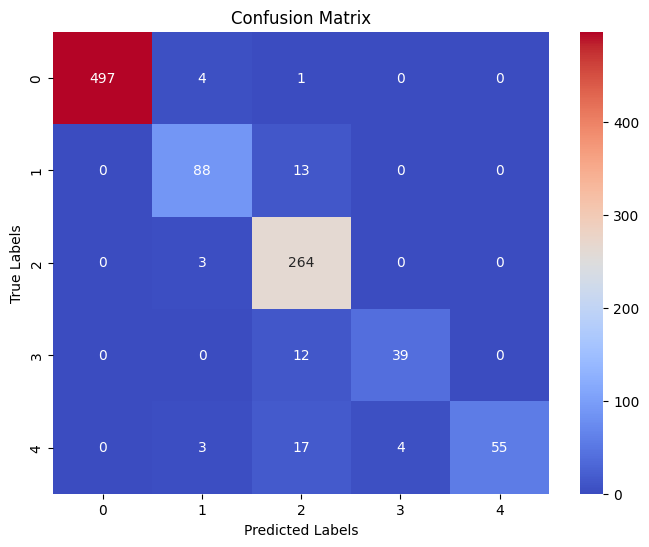

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted class: No DR


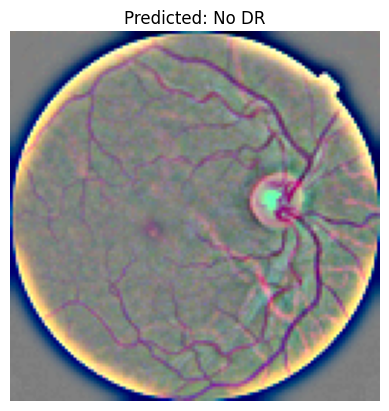

In [14]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Define class names corresponding to model outputs
class_names = ['No DR', 'Mild', 'Moderate', 'Proliferate DR', 'Severe']

# Load and preprocess the image
img_path = r'gauss_testing\no_dr\b5bea250d8bf5_0.png'  
img = load_img(img_path, target_size=(128, 128))  
img_array = img_to_array(img) 
img_array = np.expand_dims(img_array, axis=0) 
img_array = img_array / 255.0  

# Make the prediction
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0] 
predicted_class_name = class_names[predicted_class_index] 

# Print the prediction result
print(f"Predicted class: {predicted_class_name}")

# Display the image with the predicted class name
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class_name}")
plt.show()
